# Reading and preprocessing the data...

The dataset that we are using is taken from : https://www.kaggle.com/datasets/annavictoria/speed-dating-experiment/data

This dataset was gathered from speed dating events from 2002 - 2004, in which each participant would meet with every other participant of the opposite gender for a 4-minute long first date.
After the 4-minute interval concluded, participants would rate the other participant he/she just met on six attributes: attractiveness, sincerity, intelligence, fun, ambition, and shared interests.
Finally, the participant would also respond whether he/she would be interested in seeing the other participant on another date.

In [20]:
import pandas as pd
import numpy as np
from cmdstanpy import CmdStanModel
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
from sklearn.model_selection import train_test_split


In [21]:
df_full = pd.read_csv("data/Speed_Dating_Data.csv", encoding="latin1")
df_full.head()


,iid,id,gender,idg,condtn,wave,round,position,positin1,order,...,attr3_3,sinc3_3,intel3_3,fun3_3,amb3_3,attr5_3,sinc5_3,intel5_3,fun5_3,amb5_3
0,1,1.0,0,1,1,1,10,7,NaN,4,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
1,1,1.0,0,1,1,1,10,7,NaN,3,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
2,1,1.0,0,1,1,1,10,7,NaN,10,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
3,1,1.0,0,1,1,1,10,7,NaN,5,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
4,1,1.0,0,1,1,1,10,7,NaN,7,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN


In [47]:
attrs = ["attr", "sinc", "intel", "fun", "amb", "shar"]

# we must collect all iid to form the person indexes needed for hierarchical...
cols = ["iid", "dec"] + attrs

my_df = df_full[cols]
my_df.head()

,iid,dec,attr,sinc,intel,fun,amb,shar
0,1,1,6.0,9.0,7.0,7.0,6.0,5.0
1,1,1,7.0,8.0,7.0,8.0,5.0,6.0
2,1,1,5.0,8.0,9.0,8.0,5.0,7.0
3,1,1,7.0,6.0,8.0,7.0,6.0,8.0
4,1,1,5.0,6.0,7.0,7.0,6.0,6.0


In [23]:
# looking at shape and if there's missing vals...
print(my_df.shape)
print(my_df.isna().sum())

(8378, 8)
iid         0
dec         0
attr      202
sinc      277
intel     296
fun       350
amb       712
shar     1067
dtype: int64


In [24]:
# dropping data pts (rows) with missing vals...
pruned_df = my_df.dropna().copy()

print(pruned_df.shape)
pruned_df.head()

(7040, 8)


,iid,dec,attr,sinc,intel,fun,amb,shar
0,1,1,6.0,9.0,7.0,7.0,6.0,5.0
1,1,1,7.0,8.0,7.0,8.0,5.0,6.0
2,1,1,5.0,8.0,9.0,8.0,5.0,7.0
3,1,1,7.0,6.0,8.0,7.0,6.0,8.0
4,1,1,5.0,6.0,7.0,7.0,6.0,6.0


# Creating the participant index needed for hierarchical...

In [25]:
# adding the participant index into the dataframe...
pruned_df["person_idx"] = pd.factorize(pruned_df["iid"])[0] + 1
num_unique = pruned_df["person_idx"].nunique()

print(f"Number of participants: {num_unique}")
print("Minimum person_idx:", pruned_df["person_idx"].min())
print("Maximum person_idx:", pruned_df["person_idx"].max())

pruned_df.head()

Number of participants: 537
Minimum person_idx: 1
Maximum person_idx: 537


,iid,dec,attr,sinc,intel,fun,amb,shar,person_idx
0,1,1,6.0,9.0,7.0,7.0,6.0,5.0,1
1,1,1,7.0,8.0,7.0,8.0,5.0,6.0,1
2,1,1,5.0,8.0,9.0,8.0,5.0,7.0,1
3,1,1,7.0,6.0,8.0,7.0,6.0,8.0,1
4,1,1,5.0,6.0,7.0,7.0,6.0,6.0,1


# Splitting the data...

We decide to go with a 80 20 train-test split.

In [26]:
# fixed random seed for reproducibility...
np.random.seed(42)
idx = np.random.permutation(len(pruned_df))

split = int(0.8 * len(pruned_df))
train_idx = idx[:split]
test_idx = idx[split:]

train_df = pruned_df.iloc[train_idx].copy()
test_df = pruned_df.iloc[test_idx].copy()

print(train_df.shape)
print(test_df.shape)

(5632, 9)
(1408, 9)


We must address the problem in which there are participants in the test set that are not in the training set.
As we discuss in a further section, the hierarchical model estimates an intercept based on each participant, so every participant in the test set must need to appear in the training set too.
Our initial random split resulted in some participants absent from the training, so we move the corresponding rows into the training set.

In [27]:
# grabbing all unique ppl in the train and test sets...
all_train_people = set(train_df["person_idx"])
all_test_people = set(test_df["person_idx"])

missing_people = all_test_people - all_train_people

print("Number of test participants not seen in training:", len(missing_people))

# adding the missing rows into the train set...
if len(missing_people) > 0:
    missing_from_train = test_df["person_idx"].isin(missing_people)

    rows_to_add = test_df[missing_from_train].copy()
    test_df = test_df[~missing_from_train].copy()
    train_df = pd.concat([train_df, rows_to_add], axis=0).copy()

print("New train shape:", train_df.shape)
print("New test shape:", test_df.shape)

missing_people = set(test_df["person_idx"]) - set(train_df["person_idx"])
print("Number of test participants not seen in training:", len(missing_people))

Number of test participants not seen in training: 3
New train shape: (5637, 9)
New test shape: (1403, 9)
Number of test participants not seen in training: 0


# Mean centering and scaling the data...

Since we're not allowed to look at the testset in advance, we will meancenter and scale the testset wrt to the train set, since it comes from the same dataset.

In [31]:
y_train = train_df["dec"].astype(int).copy()
y_test = test_df["dec"].astype(int).copy()

# dont standardise the target var...
attrs = ["attr", "sinc", "intel", "fun", "amb", "shar"]


# compute mean and stdev of training set only...
train_mu = train_df[attrs].mean()
train_sigma = train_df[attrs].std()

X_train_standardised = (train_df[attrs] - train_mu) / train_sigma
X_test_standardised = (test_df[attrs] - train_mu) / train_sigma



# Stan-based Hierarchical Bayesian Logistic Regression

First, we define parameters $\beta_i,\forall i=1,\dots,6$ as follows:

$\beta_1$ is the weight assigned to the attractiveness attribute

$\beta_2$ is the weight assigned to the sincerity attribute

$\beta_3$ is the weight assigned to the intelligence attribute

$\beta_4$ is the weight assigned to the fun attribute

$\beta_5$ is the weight assigned to the ambition attribute

$\beta_6$ is the weight assigned to the shared interests attribute

Lastly, we define $J$ as the distinct number of participants in the dataset.

Our decision variable is binary, so hence, the appropriate likelihood is Bernoulli.
That is, for sample $n$, we have that $y_n \sim \mathrm{Bernoulli}(p_n)$.

Hierarchical Bayesian Logistic Regression is similar to the standard Bayesian Logistic Regression approach in structure.
The key difference is that rather than defining a "global" $\beta_0$ as the bias term, we introduce "local" variable $\alpha_j$ for each distinct participant, where $\alpha_j$ represents that person's baseline tendency. 
Additionally, we define $\mu_\alpha$ as the average baseline tendency across all participants and $\sigma_\alpha$ as the standard deviation of all participants' $\alpha_j$. 
Then, we have 
$$
\alpha_j \sim \mathcal{N}(\mu_\alpha, \sigma_\alpha), \quad \forall j \in 1,\dots,J.
% \alpha_1, \alpha_2, \dots, \alpha_J
$$

This approach more intuitively aligns with cognitive modeling, since even with the same information, people may be naturally more selective while others are naturally less, and hence reach different conclusions.

Then, we have that our Bayesian Logistic Regression formula probability for sample $n$ is formulated as follows: 
$$
\mathrm{logit}(p_n) = \alpha_{j[n]}
+ \sum_{i=1}^6 \beta_i x_{n,i}
$$
where $j[n]$ denotes the participant associated with sample $n$, and $\beta_i \sim \mathcal{N}(0, 2.5), \forall i=1,\dots,6$.
Also, 
$$
\mu_\alpha \sim \mathcal{N}(0,2.5) \\
\sigma_\alpha \sim \mathrm{Exponential}(1).
$$

Then, we obtain $p_n$ itself through the sigmoid function, which is 
$$
\frac{1}{1 + \exp\left[- (\alpha_{j[n]}
+ \sum_{i=1}^6 \beta_i x_{n,i})\right]}
.
$$

In [40]:
attrs = ["attr", "sinc", "intel", "fun", "amb", "shar"]

data_dict = {
    "num_feats": len(attrs),
    "num_unique": num_unique,

    # train set...
    "N_train": len(y_train),
    "y_train": y_train.to_numpy().astype(int),
    "X_train": X_train_standardised.to_numpy(),
    "person_train": train_df["person_idx"].to_numpy().astype(int),

    # test set...
    "N_test": len(y_test),
    "X_test": X_test_standardised.to_numpy(),
    "person_test": test_df["person_idx"].to_numpy().astype(int)
}

model = CmdStanModel(stan_file="models/hierarchical_bayesian_lr.stan")
fit = model.sample(data=data_dict, chains=4, iter_sampling=2500, iter_warmup=1000)

22:06:56 - cmdstanpy - INFO - compiling stan file C:\Users\ronin\OneDrive\Pictures\cogmod\CogMod-HWs\finalproj\models\hierarchical_bayesian_lr.stan to exe file C:\Users\ronin\OneDrive\Pictures\cogmod\CogMod-HWs\finalproj\models\hierarchical_bayesian_lr.exe
22:07:23 - cmdstanpy - INFO - compiled model executable: C:\Users\ronin\OneDrive\Pictures\cogmod\CogMod-HWs\finalproj\models\hierarchical_bayesian_lr.exe
22:07:23 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/3500 [00:00<?, ?it/s, (Warmup)]


chain 1:   3%|▎         | 100/3500 [00:08<04:34, 12.39it/s, (Warmup)]


chain 1:   9%|▊         | 300/3500 [00:11<01:38, 32.59it/s, (Warmup)]


chain 1:  11%|█▏        | 400/3500 [00:12<01:14, 41.58it/s, (Warmup)]


chain 1:  14%|█▍        | 500/3500 [00:14<01:01, 48.44it/s, (Warmup)]


chain 1:  17%|█▋        | 600/3500 [00:15<00:52, 55.49it/s, (Warmup)]


chain 1:  20%|██        | 700/3500 [00:16<00:44, 62.69it/s, (Warmup)]


chain 1:  23%|██▎       | 800/3500 [00:1


22:08:24 - cmdstanpy - INFO - CmdStan done processing.


In [41]:
summary = fit.summary()
summary

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,-2161.670000,0.531997,24.007500,24.088200,-2201.430000,-2161.640000,-2122.230000,2034.00,3856.58,13.3037,1.003280
mu_alpha,-0.730188,0.002847,0.112341,0.112366,-0.915755,-0.730881,-0.544037,1559.27,3386.28,10.1987,1.001230
sigma_alpha,2.282070,0.002267,0.116992,0.114540,2.094750,2.280380,2.481560,2674.26,4166.78,17.4914,1.002390
alpha_raw[1],0.864626,0.004279,0.466467,0.442542,0.132447,0.840377,1.677330,12857.20,6729.42,84.0945,1.000890
alpha_raw[2],-0.189190,0.003190,0.362923,0.352417,-0.796035,-0.182386,0.399804,13106.70,6588.56,85.7266,1.001510
...,...,...,...,...,...,...,...,...,...,...,...
y_sim[1399],0.034900,NaN,0.183536,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
y_sim[1400],0.035000,0.001848,0.183789,0.000000,0.000000,0.000000,0.000000,9954.20,5000.00,65.1070,0.999967
y_sim[1401],0.054800,NaN,0.227601,0.000000,0.000000,0.000000,1.000000,NaN,NaN,NaN,NaN
y_sim[1402],0.284200,NaN,0.451055,0.000000,0.000000,0.000000,1.000000,10155.10,10155.10,66.4209,1.000860


In [48]:
parameter_names = {
    "mu_alpha": "Intercept",
    "sigma_alpha": "Between-person variability",
    "beta[1]": "Attractiveness",
    "beta[2]": "Sincerity",
    "beta[3]": "Intelligence",
    "beta[4]": "Fun",
    "beta[5]": "Ambition",
    "beta[6]": "Shared interests",
}

detailed_summary = summary.loc[
    ["mu_alpha", "sigma_alpha", "beta[1]", "beta[2]", "beta[3]", "beta[4]", "beta[5]", "beta[6]"],
    ["Mean", "StdDev", "5%", "50%", "95%", "ESS_bulk", "ESS_tail", "ESS_bulk/s", "R_hat"]]


detailed_summary.index = detailed_summary.index.map(parameter_names)

detailed_summary

,Mean,StdDev,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
Intercept,-0.730188,0.112341,-0.915755,-0.730881,-0.544037,1559.27,3386.28,10.1987,1.001230
Between-person variability,2.282070,0.116992,2.094750,2.280380,2.481560,2674.26,4166.78,17.4914,1.002390
Attractiveness,1.714080,0.075626,1.588810,1.715560,1.836780,7994.35,7792.48,52.2882,1.000510
Sincerity,0.125668,0.071934,0.005698,0.126019,0.243393,7600.49,7643.09,49.7121,1.000200
Intelligence,0.261907,0.077251,0.136366,0.263259,0.388344,7815.37,7624.26,51.1176,1.000490
Fun,0.865675,0.074045,0.741649,0.866147,0.987951,8823.30,6932.92,57.7101,0.999891
Ambition,-0.123200,0.069576,-0.236599,-0.123255,-0.008410,8071.04,7668.91,52.7898,1.000110
Shared interests,0.851156,0.069244,0.735775,0.850687,0.966098,7547.99,7152.58,49.3688,1.000270


Generating traceplot...

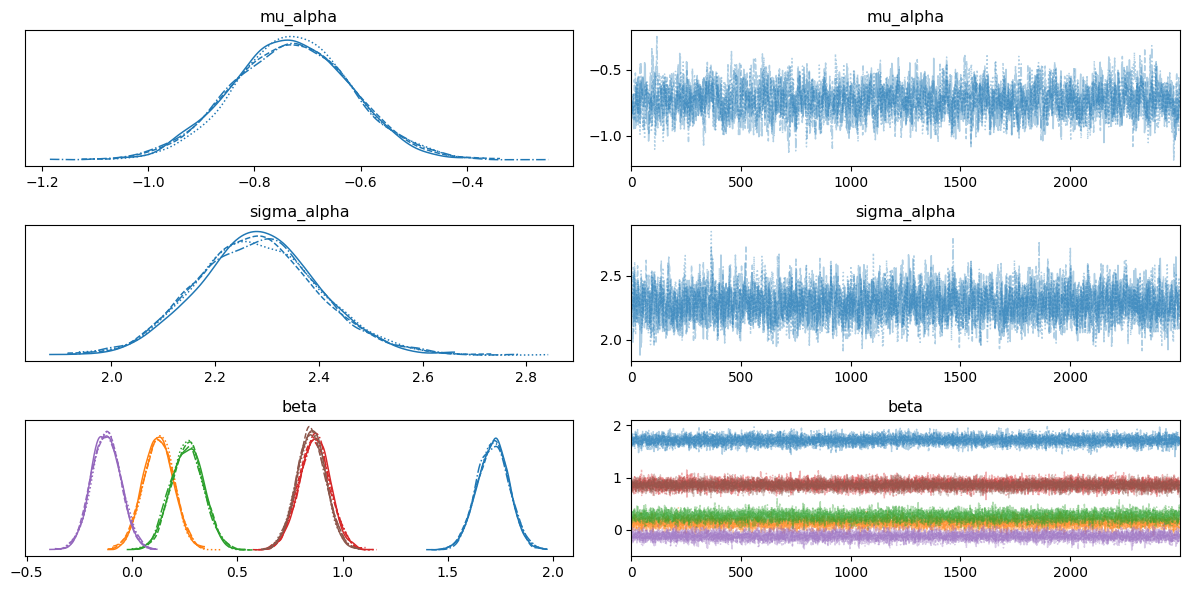

In [44]:
# Traceplots and marginals - visual convergence checks
axarr = az.plot_trace(fit, var_names=["mu_alpha", "sigma_alpha","beta"])
plt.tight_layout()

# Predictive Model Accuracy

In [45]:
# extracting the predicted probabilities for the test set...
p_hat_samples = fit.stan_variable("p_hat")

# calculating mean predicted probability...
p_bar = p_hat_samples.mean(axis=0)

# brier score (as taken from hw pdf)...
brier_score = ((p_bar - y_test.to_numpy())**2).mean()

# calculating accuracy on the test set...
predictions = (p_bar > 0.5).astype(int)
accuracy = (predictions == y_test.to_numpy()).mean()

print(f"Brier Score: {brier_score:.4f}")
print(f"Test Set Accuracy: {accuracy:.2%}")

Brier Score: 0.1103
Test Set Accuracy: 84.39%


# Generative Model Accuracy

In [46]:
# extracing simulated decisions from fitted model...
y_sim_samples = fit.stan_variable("y_sim")

# calculating the "yes" rates for ground truth and our model...
gt_yes = y_test.mean()
y_sim_yes = y_sim_samples.mean()

abs_err = abs(gt_yes - y_sim_yes)
print(f"Ground Truth Yes Rate: {gt_yes:.2%}")
print(f"Simulated Yes Rate: {y_sim_yes:.2%}")
print(f"Posterior Predictive Error: {abs_err:.4f}")


Ground Truth Yes Rate: 43.05%
Simulated Yes Rate: 42.33%
Posterior Predictive Error: 0.0072
